# Chapter 1: Describing and Understanding Data


In this notebook, we use Python to explore the main ideas from Chapter 1.

We will work with simple examples to understand:

- measures of center
- measures of spread
- outliers
- skewness and kurtosis
- relationships between variables


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\mrezaira\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\mrezaira\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Coffee Shop Daily Sales Data

In [2]:
sales = [120, 125, 128, 130, 122, 127,
         129, 131, 126, 124, 123, 135]

sales


[120, 125, 128, 130, 122, 127, 129, 131, 126, 124, 123, 135]

## Mean

In [3]:
mean_sales = np.mean(sales)

print("Mean daily sales:", round(mean_sales, 2))


Mean daily sales: 126.67


## Median

In [4]:
median_sales = np.median(sales)

print("Median daily sales:", median_sales)


Median daily sales: 126.5


## Effect of an Outlier

In [5]:
sales_outlier = [120, 125, 128, 130, 122, 127,
                 129, 131, 126, 124, 123, 300]

mean_outlier = np.mean(sales_outlier)
median_outlier = np.median(sales_outlier)

print("Mean with outlier:", round(mean_outlier, 2))
print("Median with outlier:", median_outlier)


Mean with outlier: 140.42
Median with outlier: 126.5


## Visual Comparison

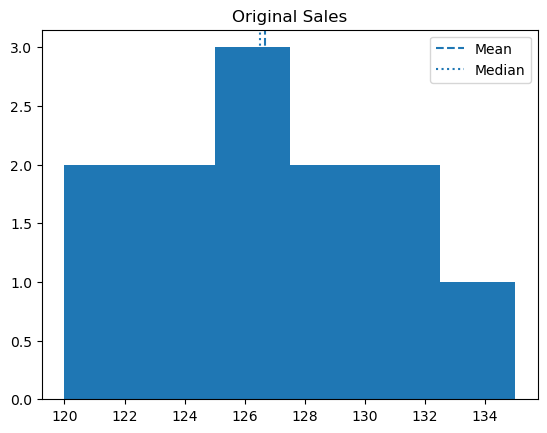

In [6]:
# Original sales data

plt.hist(sales, bins=6)

plt.axvline(np.mean(sales), linestyle='--', label='Mean')
plt.axvline(np.median(sales), linestyle=':', label='Median')

plt.title("Original Sales")
plt.legend()

plt.show()


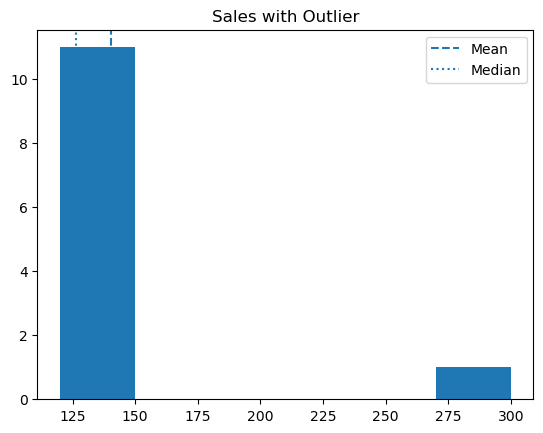

In [7]:
# Sales data with an outlier

plt.hist(sales_outlier, bins=6)

plt.axvline(np.mean(sales_outlier), linestyle='--', label='Mean')
plt.axvline(np.median(sales_outlier), linestyle=':', label='Median')

plt.title("Sales with Outlier")
plt.legend()

plt.show()

## Weighted Mean

In [8]:
# Scores earned in each course component

scores = [80, 70, 90]

# Contribution of each component to the final grade
# Assignments = 40%
# Midterm = 25%
# Final Exam = 35%

weights = [0.40, 0.25, 0.35]

# Calculate the weighted mean

weighted_mean = np.average(scores, weights=weights)

print("Weighted mean:", weighted_mean)

Weighted mean: 81.0


## Quartiles

In [9]:
# Returning to the coffee shop sales example

q1 = np.percentile(sales, 25)
q2 = np.percentile(sales, 50)
q3 = np.percentile(sales, 75)

print("Q1:", q1)
print("Q2 (Median):", q2)
print("Q3:", q3)


Q1: 123.75
Q2 (Median): 126.5
Q3: 129.25


## Interquartile Range (IQR)

In [10]:
iqr = q3 - q1

print("IQR:", iqr)


IQR: 5.5


## Detecting Outliers

In [11]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower boundary:", lower_bound)
print("Upper boundary:", upper_bound)

outliers = []

for value in sales_outlier:
    if value < lower_bound or value > upper_bound:
        outliers.append(value)

print("Outliers:", outliers)


Lower boundary: 115.5
Upper boundary: 137.5
Outliers: [300]


## Boxplot

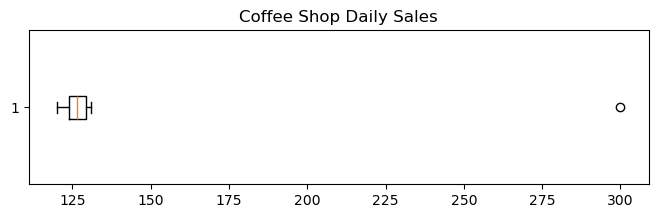

In [12]:
plt.figure(figsize=(8, 2))

plt.boxplot(sales_outlier, vert=False)

plt.title("Coffee Shop Daily Sales")

plt.show()


## Range

In [13]:
data_range = max(sales) - min(sales)

print("Range:", data_range)


Range: 15


## Variance and Standard Deviation

In [14]:
variance = np.var(sales)
std_dev = np.std(sales)

print("Variance:", round(variance, 2))
print("Standard deviation:", round(std_dev, 2))


Variance: 16.39
Standard deviation: 4.05


## Skewness and Kurtosis

In [15]:
from scipy.stats import skew, kurtosis


In [16]:
sales_skewness = skew(sales)
sales_outlier_skewness = skew(sales_outlier)

print("Skewness (original):", round(sales_skewness, 2))
print("Skewness (with outlier):", round(sales_outlier_skewness, 2))


Skewness (original): 0.3
Skewness (with outlier): 3.01


In [17]:
sales_kurtosis = kurtosis(sales)
sales_outlier_kurtosis = kurtosis(sales_outlier)

print("Kurtosis (original):", round(sales_kurtosis, 2))
print("Kurtosis (with outlier):", round(sales_outlier_kurtosis, 2))


Kurtosis (original): -0.51
Kurtosis (with outlier): 7.09


## Study Hours and Exam Scores

In [18]:
study_hours = [1, 2, 3, 4, 5, 6, 7, 8]

exam_scores = [52, 55, 61, 65, 72, 78, 85, 90]


## Scatterplot

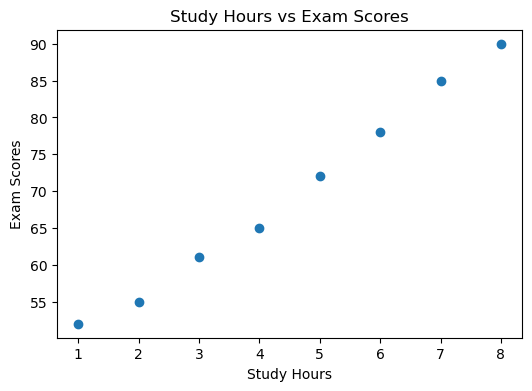

In [19]:
plt.figure(figsize=(6, 4))

plt.scatter(study_hours, exam_scores)

plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Study Hours vs Exam Scores")

plt.show()


## Covariance

In [20]:
cov_matrix = np.cov(study_hours, exam_scores)

print(cov_matrix)


[[  6.          33.85714286]
 [ 33.85714286 192.5       ]]


## Correlation

In [21]:
correlation = np.corrcoef(study_hours, exam_scores)

print(correlation)


[[1.         0.99622931]
 [0.99622931 1.        ]]


## Anscombe’s Quartet

In [22]:
anscombe = pd.read_csv(
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/anscombe.csv"
)

anscombe.head()


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [23]:
# Calculate the mean and standard deviation
# for each dataset in Anscombe’s Quartet

anscombe.groupby('dataset').agg({
    'x': ['mean', 'std'],
    'y': ['mean', 'std']
})

x                   y          
        mean       std      mean       std
dataset                                   
I        9.0  3.316625  7.500909  2.031568
II       9.0  3.316625  7.500909  2.031657
III      9.0  3.316625  7.500000  2.030424
IV       9.0  3.316625  7.500909  2.030579

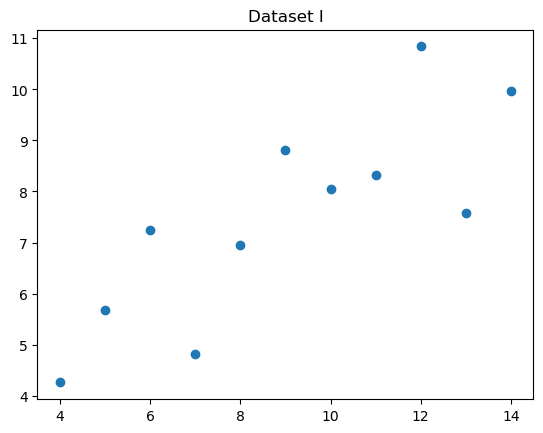

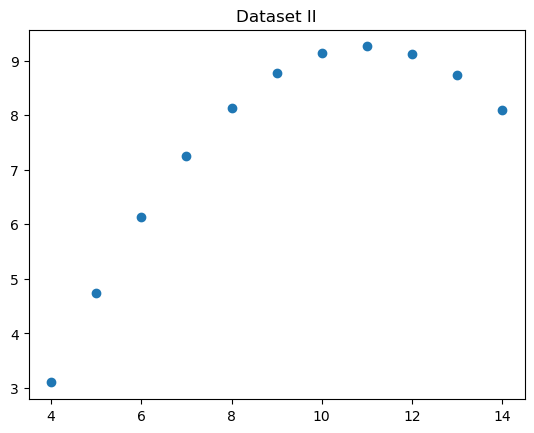

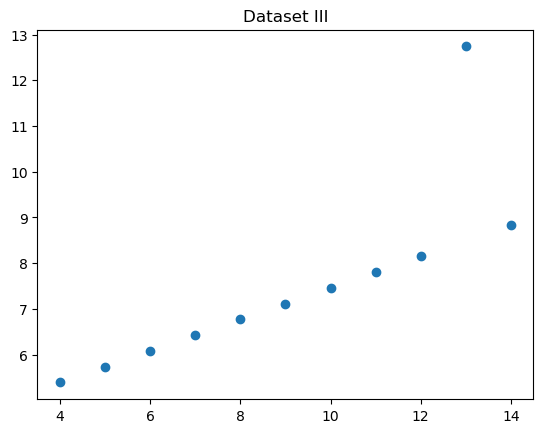

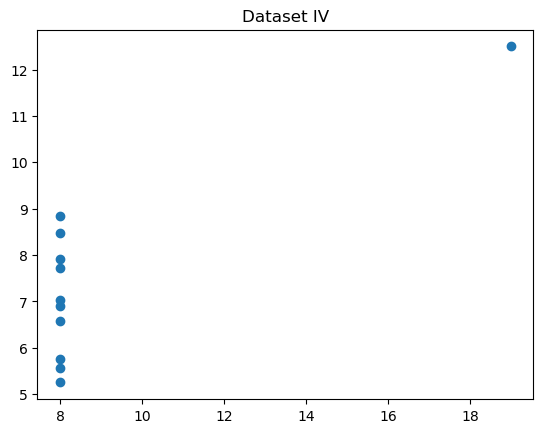

In [24]:
# Despite having nearly identical summary statistics,
# the four datasets behave very differently when visualized.

# Dataset I

dataset_1 = anscombe[anscombe['dataset'] == 'I']

plt.scatter(dataset_1['x'], dataset_1['y'])

plt.title("Dataset I")

plt.show()


# Dataset II

dataset_2 = anscombe[anscombe['dataset'] == 'II']

plt.scatter(dataset_2['x'], dataset_2['y'])

plt.title("Dataset II")

plt.show()


# Dataset III

dataset_3 = anscombe[anscombe['dataset'] == 'III']

plt.scatter(dataset_3['x'], dataset_3['y'])

plt.title("Dataset III")

plt.show()


# Dataset IV

dataset_4 = anscombe[anscombe['dataset'] == 'IV']

plt.scatter(dataset_4['x'], dataset_4['y'])

plt.title("Dataset IV")

plt.show()